---
# VGG16 : `MNIST` (avec `Keras`)
---

## Packages

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.datasets import mnist

import tensorflow as tf

---
## 1. Données
---

### 1.1. Importation

In [ ]:
(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=1/5)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

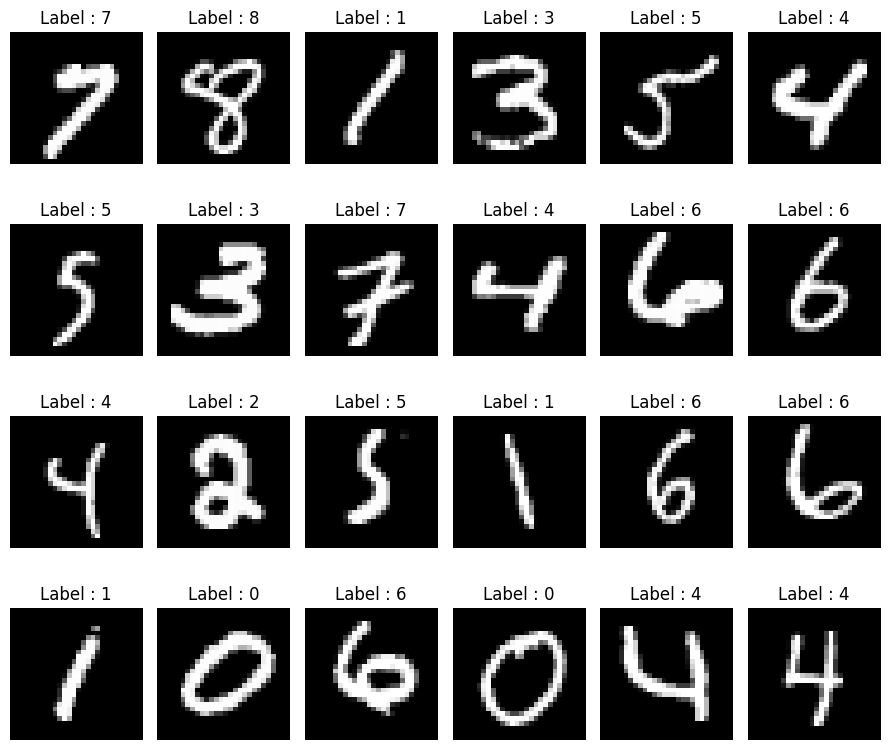

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Redimensionnement

On met les images au format $48\times 48$ pixels, sur 3 niveaux de couleur (RGB) :

In [4]:
dim_inputs_new = 48
n_colors       = 3

def resize_images(images):
  images = images.astype('float32')
  images = np.expand_dims(images, axis=-1)
  images = np.repeat(images, n_colors, axis=-1)
  images = tf.image.resize(images, [dim_inputs_new, dim_inputs_new])
  return images

X_train = resize_images(X_train)
X_valid = resize_images(X_valid)
X_test  = resize_images(X_test)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

Dimensions de X_train : (48000, 48, 48, 3)
Dimensions de X_valid : (12000, 48, 48, 3)
Dimensions de X_test  : (10000, 48, 48, 3)


### 1.4. Normalisation

Pour utiliser VGG16, on normalise les données en retirant les moyennes de chaque niveau de couleur sur le jeu de données imageNet (challenge) :

In [5]:
X_train_norm = preprocess_input(X_train)
X_valid_norm = preprocess_input(X_valid)
X_test_norm  = preprocess_input(X_test)

---
## 2. VGG16
---

### 2.1. Architecture

In [6]:
dim_outputs = 10

n_units_hl = 256
dropout_hl = 0.2

model = keras.models.Sequential(name='CNN')

activation_input  = 'relu'
activation_output = 'softmax'

optimizer = 'adam'
loss      = 'categorical_crossentropy'
metrics   = ['accuracy']

input_tensor = layers.Input(shape=(dim_inputs_new, dim_inputs_new, n_colors))

model_prior = VGG16(weights='imagenet',
                    include_top=False,
                    input_tensor=input_tensor)

x = layers.Flatten()(model_prior.output)
x = layers.Dense(units=n_units_hl, activation=activation_input)(x)
x = layers.Dropout(rate=dropout_hl)(x)
output = layers.Dense(units=dim_outputs, activation=activation_output)(x)

model = models.Model(inputs=input_tensor, outputs=output)

for layer in model_prior.layers:
    layer.trainable = False

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 48, 48, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 48, 48, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 2.2. Optimiseur

In [ ]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [8]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - accuracy: 0.6349 - loss: 2.4813 - val_accuracy: 0.9134 - val_loss: 0.2778
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.9000 - loss: 0.3221 - val_accuracy: 0.9333 - val_loss: 0.2157
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9271 - loss: 0.2278 - val_accuracy: 0.9440 - val_loss: 0.1787
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9387 - loss: 0.1915 - val_accuracy: 0.9504 - val_loss: 0.1598
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9475 - loss: 0.1617 - val_accuracy: 0.9522 - val_loss: 0.1510
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - accuracy: 0.9539 - loss: 0.1474 - val_accuracy: 0.9539 - val_loss: 0.1451
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9574 - loss: 0.1299 - val_accuracy: 0.9583 - val_loss: 0.1347
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.9612 - loss: 0

### 2.4. Prévisions

In [9]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


array([[1.5100895e-15, 1.8866941e-09, 1.5559353e-06, 3.3495647e-11,
        1.2117346e-08, 2.4787253e-10, 8.1308105e-13, 9.9999845e-01,
        9.7083539e-13, 1.7363546e-09],
       [6.5046997e-13, 5.0641630e-10, 9.9999964e-01, 1.0761213e-09,
        2.8795711e-08, 3.0904030e-07, 1.0831859e-14, 1.9195427e-09,
        3.6969147e-15, 2.6369876e-10],
       [1.6079014e-15, 1.0000000e+00, 1.4690025e-13, 1.9480625e-16,
        1.8192095e-11, 7.9165577e-11, 6.9365062e-11, 2.6040726e-12,
        6.8739683e-16, 1.2710156e-12],
       [1.0000000e+00, 2.3674167e-11, 5.9965060e-09, 5.2333904e-16,
        2.8054767e-09, 4.7167115e-10, 3.0762706e-08, 1.0743052e-08,
        2.0262978e-09, 1.2979953e-10],
       [8.2595015e-09, 7.7073302e-08, 5.7221197e-08, 9.8096120e-10,
        9.9999678e-01, 7.5520495e-07, 1.7404660e-06, 2.8079357e-09,
        3.5888039e-08, 5.7397051e-07]], dtype=float32)

In [10]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [11]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.1261
Exactitude test : 0.9656
